# Game Theory on Complex Networks
Playground to figure out network generation, update rules and simulations.

In [1]:
import networkx as nx 
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 

np.random.seed(13)

### 1. Network Generation
Let's try to implement the network generation as described by [Gómez-Gardeñes et al., 2006](http://dx.doi.org/10.1103/PhysRevE.73.056124)

In [2]:
def generate_mixed_network(N:int=1000, alpha:float=0.0, m:int=4, m0_frac:float=0.1) -> nx.Graph:
    """Generates network according to mixed model by Gómez-Gardeñes and Moreno (2006),
    which interpolates between ER and BA model through the heterogeneity parameter alpha.

    Args:
        N (int, optional): Number of nodes. Defaults to 1000.
        alpha (float, optional): Heterogeneity parameter, can have values from 0 (BA-graph) 
            to 1 (ER-graph). Defaults to 0.0.
        m (int, optional): Number of edges added at each growth step. Defaults to 6.
        m0_frac (float, optional): Fraction of total nodes to form the initial fully connected
            graph before the growing process. Defaults to 0.1.

    Returns:
        nx.Graph: Output networkx graph.
    """
    m0 = int(N*m0_frac)
    G = nx.complete_graph(m0)  # initialise fully connected network with m0 nodes
    U_idx = np.arange(m0, N) # indices of N-m0 initially unconnected nodes
    G.add_nodes_from(U_idx)  # add the N-m0 unconnected nodes

    # we'll have to go through all N-m0 unconnected nodes, each selected randomly
    # let's do this by shuffeling the index list and go through the nodes in the
    # obtained random order
    np.random.shuffle(U_idx)

    for idx in U_idx:
        # create m links:
        for _ in range(m):
            # (re)compute node probs:
            E = G.number_of_edges() # TODO: catch cases with no initial edges etc!
            # with probability alpha select a uniformly random one of all nods
            # with probability 1-alpha select node via preferential attachment
            probs = np.array([(1.0-alpha)*val/(2*E - G.degree(idx)) + alpha*1/(N-1) for (node, val) in G.degree() if node != idx])
            #print(probs.sum())
            #print(probs.shape)
            node = np.random.choice(np.delete(np.arange(N), idx), p=probs)
            G.add_edge(idx, node)

    return G

50
163


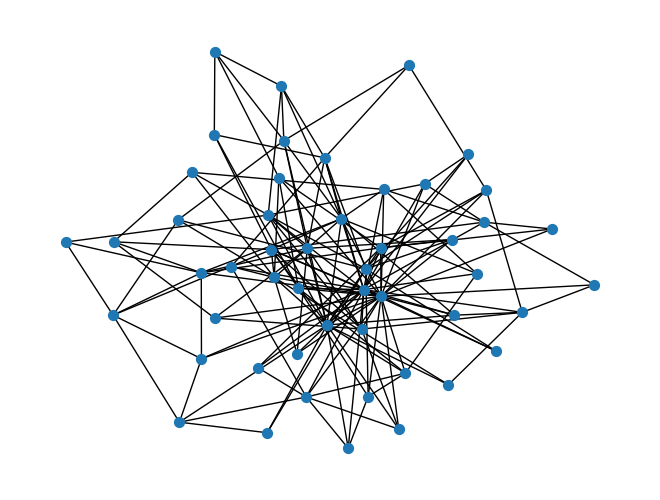

In [3]:
G = generate_mixed_network(N=50)
print(G.number_of_nodes())
print(G.number_of_edges())
nx.draw(G, node_size=50)

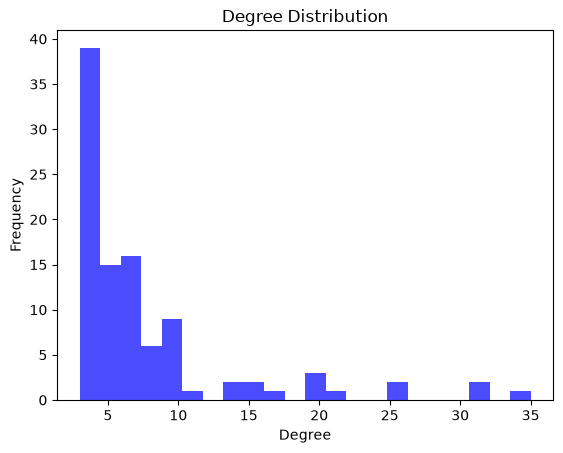

In [4]:
# plot degree distribution
G = generate_mixed_network(N=100)
degree_sequence = sorted([d for n, d in G.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

### Running the Ultimatum game
Time to figure this out!
- Each node has a strategy (p, q) -> add strategy as node attribute
- Figure out how to run 1 time step where each node plays with each of its neighbors and accumulates payoff -> also track payoff as node attribute?
- first initialize, then play!
- each node has an update rule (MOR, REP, UI, ...) to be added as node attribute (but that's for later)

Defining the update rules:

In [5]:
def MOR_update(G: nx.Graph, node):
    node_data = G.nodes[node]
    neighbors = list(G.neighbors(node))
    neighbors.append(node)
    # build payoff array
    nb_payoffs = np.array([G.nodes[nb]["payoff"] for nb in neighbors])
    total = nb_payoffs.sum()
    # if no payoff has been obtained, just keep the current strategy for now
    # to avoid division by zero
    # TODO: REPLACE WITH UNIFORMLY RANDOM CHOICE, WHICH MAKES MORE SENSE (I think)
    if total <= 0: # so if no payoff has been obtained at all
        return node_data["strategy"], node_data["update_rule"]
    # choose neighbor with probability proportional to payoff
    nb_chosen = G.nodes[neighbors[np.random.choice(len(neighbors), p=nb_payoffs/total)]]
    return nb_chosen["strategy"], nb_chosen["update_rule"]

def REP_update(G: nx.Graph, node):
    # corresponds to the "natural selection" rule
    node_data = G.nodes[node]
    # choose random neighbor nb
    nb = random.choice(list(G.neighbors(node)))
    nb_data = G.nodes[nb]
    # compute replication probability from payoff difference
    prob = max(0, (nb_data["payoff"] - node_data["payoff"])/(2*max(G.degree(node), G.degree(nb))))

    if np.random.uniform() < prob: # copy nb
        return nb_data["strategy"], nb_data["update_rule"]
    else: # keep current strategy/update rule
        return node_data["strategy"], node_data["update_rule"]
    
    # NOTE TO SELF: KEEP IN MIND THAT UPDATES NEED TO HAPPEN SIMULATANEOUSLY! DO NOT OVERWRITE
    # ANY OF THE STRATEGIES/UPDATE RULES UNTIL ALL NODES HAVE BEEN EVALUTATED!!!
    # BUILD A DICT OF THE NEW THINGS FIRST AND THEN ASSIGN THE NEW ATTRIBUTES
    # determine whether or not to copy neighbor strategy & update rule


def UI_update(G: nx.Graph, node):
    node_data = G.nodes[node]
    # get neighbor with highest payoff and copy if better
    best_nb = max(list(G.neighbors(node)), key=lambda nb: G.nodes[nb]["payoff"])
    best_data = G.nodes[best_nb]

    if best_data["payoff"] > node_data["payoff"]:
        return best_data["strategy"], best_data["update_rule"]
    else:
        return node_data["strategy"], node_data["update_rule"]

# dict of update rules pointing to the implemented update functions
UPDATE_RULES_DICT = {
    "MOR": MOR_update,
    "REP": REP_update,
    "UI": UI_update
}

Initialise UG and perform a single round:

In [6]:
def init_UG(G: nx.graph, update_rules, update_ratios, mode:str="fair"):
    # initialise the ultimatum game by assigning initial strategies, update rules
    # and payoffs for each of the nodes in the graph
    N = G.number_of_nodes()  # number of nodes
    node_idx = np.arange(N)  # node indices

    # generate strategies
    if mode == "fair":  # p = q
        p_vals = np.random.uniform(size=(N, 1)) 
        strategy_vals = np.column_stack([p_vals, p_vals])
    elif mode == "pragmatic":  # p = 1-q 
        p_vals = np.random.uniform(size=(N, 1))
        strategy_vals = np.column_stack([p_vals, 1-p_vals])
    elif mode == "independent":  # p, q independent
        strategy_vals = np.random.uniform(size=(N, 2))
    else: # invalide mode
        raise ValueError(f"Invalid mode argument. Mode must be 'fair', 'pragmatic', or 'independent'. Given mode: {mode}.")
    # make dictionary with node indices to assign it as node attribute
    strategies = dict(zip(node_idx, strategy_vals))

    # generate update rules
    # we want to randomly assign them to nodes, with the proportions specified by update_ratios
    # or at least as closely as we can
    update_ratios = np.array(update_ratios, dtype=float)
    update_ratios /= sum(update_ratios) # ensure they're normalized
    update_counts_raw = N*update_ratios # figure out the corresponding counts
    update_counts = np.floor(update_counts_raw).astype(int) # round down to integers 
    remaining_slots = N - update_counts.sum() # check how many (if any) slots are missing through the rounding
    if remaining_slots > 0: # increase counts of those with the biggest difference if necessary
        update_counts[np.argsort(update_counts_raw-update_counts)[:N - update_counts.sum()]] += 1
    print(update_rules, update_counts)
    update_keys = np.repeat(update_rules, update_counts) # generate array of update rules
    np.random.shuffle(update_keys) # shuffle for random assignment
    update_rules_mapped = dict(zip(node_idx, update_keys)) # make a dictionary mapping to node indices

    # assign strategies
    nx.set_node_attributes(G, strategies, name="strategy")
    # assign update rules
    nx.set_node_attributes(G, update_rules_mapped, name="update_rule")
    # initialise payoff to 0
    nx.set_node_attributes(G, 0.0 , name="payoff")

    return strategy_vals, update_keys, np.zeros(N, dtype=float)


def run_UG_step(G: nx.Graph, return_snapshot:bool=False):
    # Perform one simulation step, consisting of accumulating payoff and updating strategies/rules.
    # Each node "plays" each neighbor by comparing the respective offers p and thresholds q and 
    # adding the obtained payoff from each game. Then, according to each node's update rule, the 
    # payoffs are compared and strategies/update rules are updated

    # reset payoffs to 0.0
    nx.set_node_attributes(G, 0.0 , name="payoff")

    # --------- Payoff resolution ------------
    # Note: right now we do not make use of knowing the player strategy (fair/pragmatic) to compute the
    # payoffs, for the sake of simplicity. Might be something to add later. 
    # go through all edges and resolve the pairwise interactions 
    for i, j in G.edges():
        # get offer p/threshold q for nodes i, j
        p_i, q_i = G.nodes[i]["strategy"]
        p_j, q_j = G.nodes[j]["strategy"]
        # compute & update payoffs
        if p_i >= q_j:  # i proposes, j responds
            G.nodes[i]["payoff"] += 1-p_i
            G.nodes[j]["payoff"] += p_i
        if p_j >= q_i:  # j proposes, i responds
            G.nodes[i]["payoff"] += p_j
            G.nodes[j]["payoff"] += 1-p_j

    # --------- Update strategies & rules ---------
    # get dicts with new strategies/update rules for each node
    strategies_new, update_rules_new, acc_payoffs = {}, {}, {}
    for n, d in G.nodes(data=True):
        update_func = UPDATE_RULES_DICT[d["update_rule"]]
        strategy_new, update_rule_new = update_func(G, n)
        strategies_new[n] = strategy_new
        update_rules_new[n] = update_rule_new
        acc_payoffs[n] = d["payoff"]
    # set new strategies/update_rules as node attributes
    nx.set_node_attributes(G, strategies_new, name="strategy")
    nx.set_node_attributes(G, update_rules_new, name="update_rule")

    if return_snapshot:
        return acc_payoffs, strategies_new, update_rules_new,

In [7]:
G = generate_mixed_network(N=10, m0_frac=0.2)
init_UG(G, update_rules=["REP"], update_ratios=[1])
for idx in G.nodes():
    n = G.nodes[idx]
    print(n["strategy"])
    print(n["update_rule"])
    print(n["payoff"])

['REP'] [10]
[0.44114855 0.44114855]
REP
0.0
[0.28119839 0.28119839]
REP
0.0
[0.11471622 0.11471622]
REP
0.0
[0.98737318 0.98737318]
REP
0.0
[0.615859 0.615859]
REP
0.0
[0.7248992 0.7248992]
REP
0.0
[0.56511214 0.56511214]
REP
0.0
[0.16428586 0.16428586]
REP
0.0
[0.11984433 0.11984433]
REP
0.0
[0.04479521 0.04479521]
REP
0.0


In [8]:
run_UG_step(G, return_snapshot=True)
for idx in G.nodes():
    n = G.nodes[idx]
    print(n["strategy"])
    print(n["update_rule"])
    print(n["payoff"])

[0.44114855 0.44114855]
REP
1.8996096392531698
[0.28119839 0.28119839]
REP
4.1500386907601685
[0.11471622 0.11471622]
REP
0.8463105346912906
[0.98737318 0.98737318]
REP
0.03788046128888245
[0.615859 0.615859]
REP
3.2488363868114405
[0.7248992 0.7248992]
REP
1.3755040218169396
[0.56511214 0.56511214]
REP
2.6454217713994934
[0.16428586 0.16428586]
REP
1.5712097303279027
[0.11984433 0.11984433]
REP
1.621956586981454
[0.04479521 0.04479521]
REP
1.6032321766692585


In [9]:
for _ in range(10):
    run_UG_step(G, return_snapshot=True)

### Running the full UG simulation

In [10]:
def run_UG_simulation(G:nx.Graph,
                      num_rounds=5000, 
                      update_rules=list(UPDATE_RULES_DICT.keys()), 
                      update_ratios=[1]*len(UPDATE_RULES_DICT.keys()),
                      mode="independent",
                      snapshot_frequency=100
                      ):
    # initialize UG
    strategies, updates, payoffs = init_UG(G, update_rules, update_ratios, mode=mode)  

    # extract graph structure that can be reused
    adj = nx.to_numpy_array(G)
    degrees = list(G.degree())

    results = []  
    for t in tqdm(range(num_rounds), desc="round"):
        # extract result data every couple of rounds to see evolution
        if t%snapshot_frequency == 0:
            payoffs, strategies_new, updates_new = run_UG_step(G, return_snapshot=True)
            results.append([t, payoffs, strategies_new, updates_new])
        else: # skip the result extraction in all other rounds
            run_UG_step(G)
            
    return results

In [ ]:
G = generate_mixed_network(N=1000)
results = run_UG_simulation(G, update_rules=["REP"], update_ratios=[1], num_rounds=2000, snapshot_frequency=50)
# takes ~ 1.5h rn, 3.58 rounds/s with 5k nodes, MOR vs REP 1:1

['REP'] [1000]


round:   0%|          | 0/1000 [00:00<?, ?it/s]

Plot preliminary results:

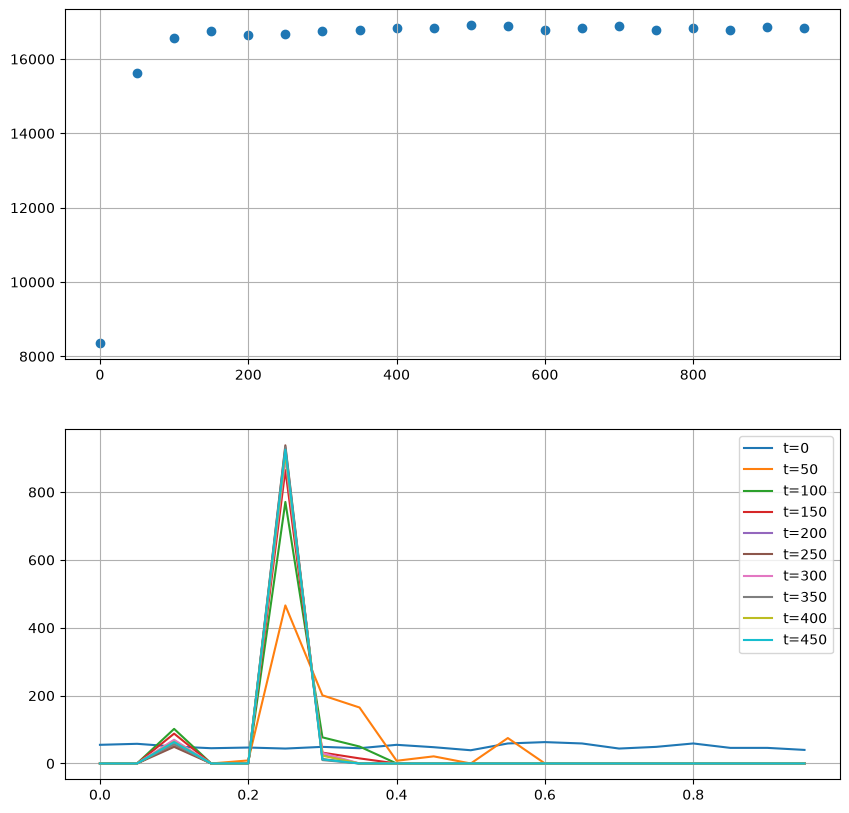

In [24]:
t = np.array([r[0] for r in results])
total_payoff = np.array([sum(r[1].values()) for r in results])
offers = np.array([[v[0] for v in r[2].values()] for r in results])

fig, ax = plt.subplots(nrows=2, figsize=(10, 10))
ax[0].scatter(t, total_payoff)
for i, ps in enumerate(offers[::2]):
    counts, edges = np.histogram(ps, bins=20, range=(0.0, 1.0))
    ax[1].plot(edges[:-1], counts, label=f"t={t[i]}")

ax[0].grid()
ax[1].grid()
ax[1].legend()

plt.show()

TODO:
- Keep track of payoff/strategy/etc as numpy array instead of node attribute to improve performance
- Try to precompute certain metrics once (e.g. list of degrees, maybe adjacency matrix/neighbor lookup?)
- add writing results to files
- setup parameter space search

So what do we want to run:
- N = 5k nodes? what if I do only 1k?
- 100/1000 realizations per setting? (Initialisation, generated network,)
- 3 alpha settings x 3 player modes x 3 update strategy pairs x 20 ratios (I'm not doing this more fine-grained) -> 540 combinations? 
- for ~10k time steps? -> probably less sufficient (maybe figure out conditions for stopping sims dynamically when stationary state is reached)

... boy oh boy this needs to be faster